In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
%matplotlib inline

In [5]:
nav = pd.read_csv("01_fund_master.csv")
nav.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
nav = pd.read_csv("02_nav_history.csv")
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


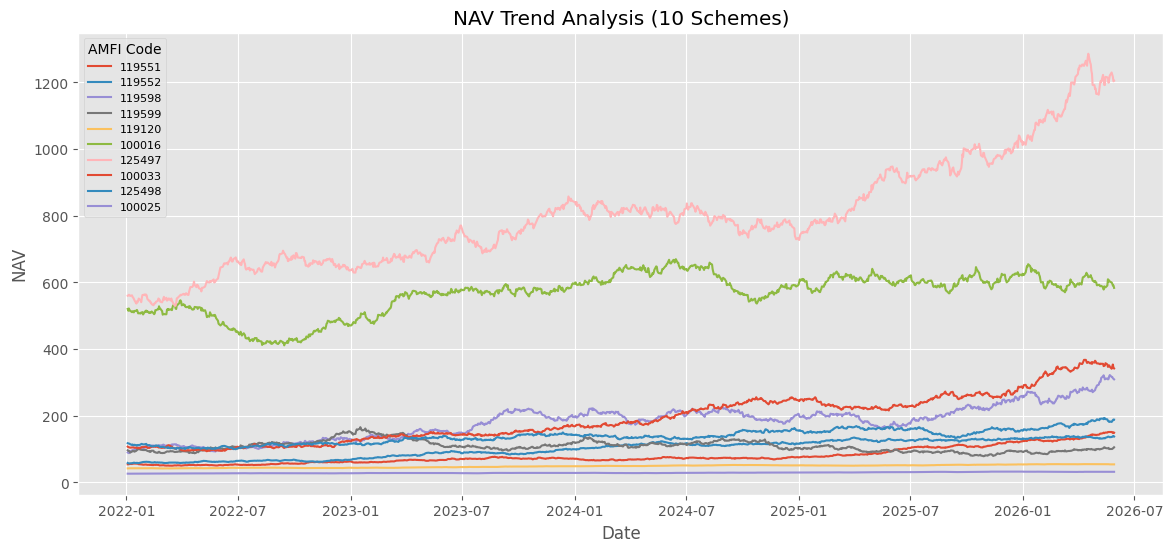

In [12]:
nav['date'] = pd.to_datetime(nav['date'])

top_schemes = nav['amfi_code'].unique()[:10]

plt.figure(figsize=(14,6))

for code in top_schemes:
    data = nav[nav['amfi_code'] == code]
    plt.plot(data['date'], data['nav'], label=str(code))

plt.title("NAV Trend Analysis (10 Schemes)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(title="AMFI Code", fontsize=8)
plt.grid(True)
plt.savefig("NAV_Trend_Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
aum = pd.read_csv("03_aum_by_fund_house.csv")
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [14]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

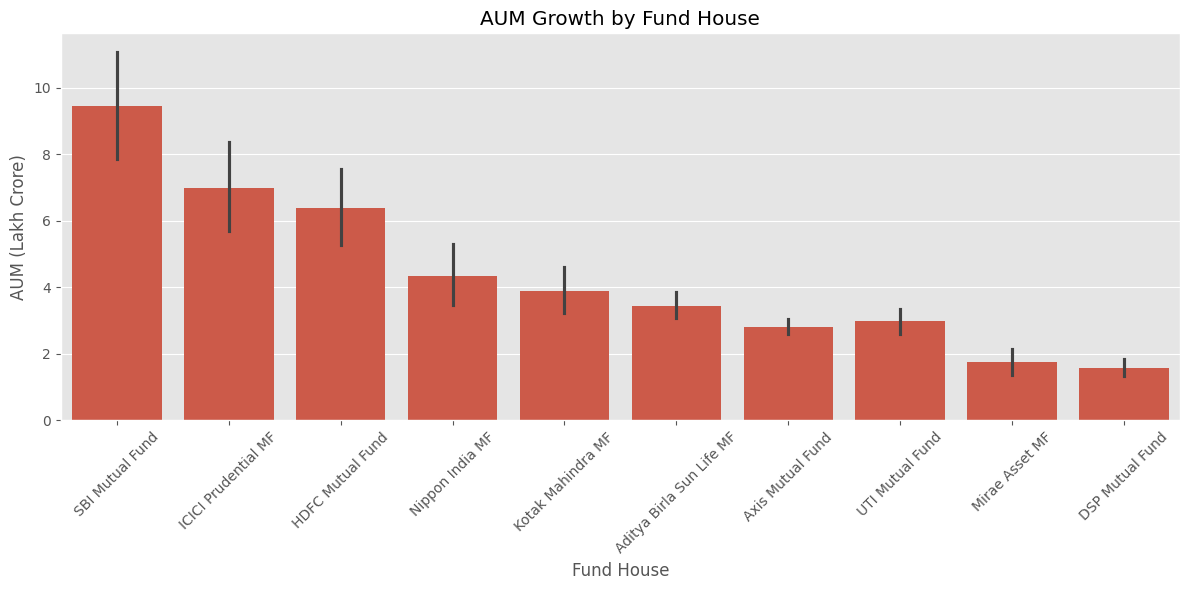

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore"
)

plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.tight_layout()

plt.savefig("AUM_Growth_Bar_Chart.png", dpi=300)

plt.show()

In [16]:
sip = pd.read_csv("04_monthly_sip_inflows.csv")
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,20.31
1,2022-02,11438,4.93,8.20,4.85,20.31
2,2022-03,12328,5.09,10.50,5.01,20.31
3,2022-04,11863,5.48,9.52,5.12,20.31
4,2022-05,12286,5.55,8.10,5.15,20.31


In [17]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

In [20]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,20.31
1,2022-02,11438,4.93,8.20,4.85,20.31
2,2022-03,12328,5.09,10.50,5.01,20.31
3,2022-04,11863,5.48,9.52,5.12,20.31
4,2022-05,12286,5.55,8.10,5.15,20.31


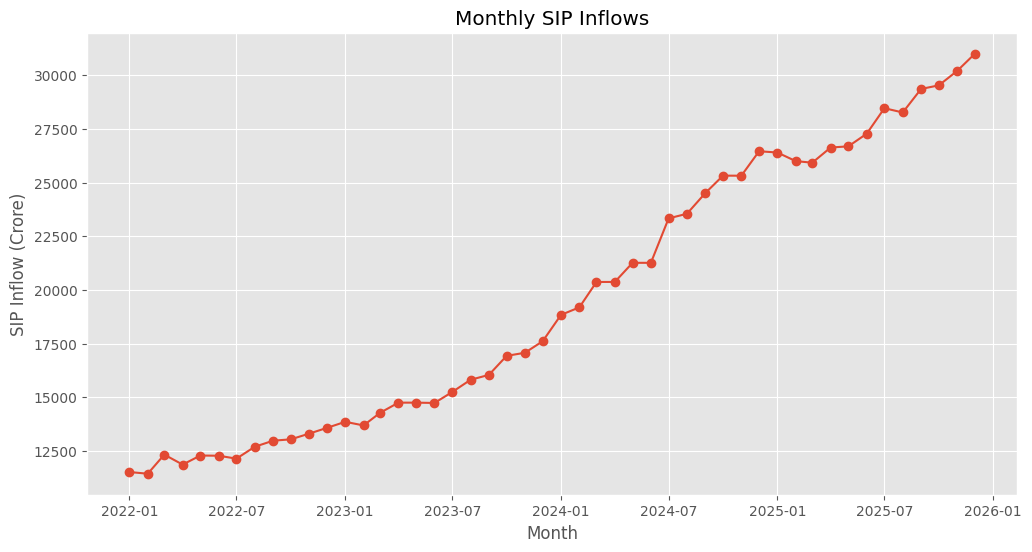

In [21]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))
plt.plot(sip['month'], sip['sip_inflow_crore'], marker='o')

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.savefig("Monthly_SIP_Inflows.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
category = pd.read_csv("05_category_inflows.csv")
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


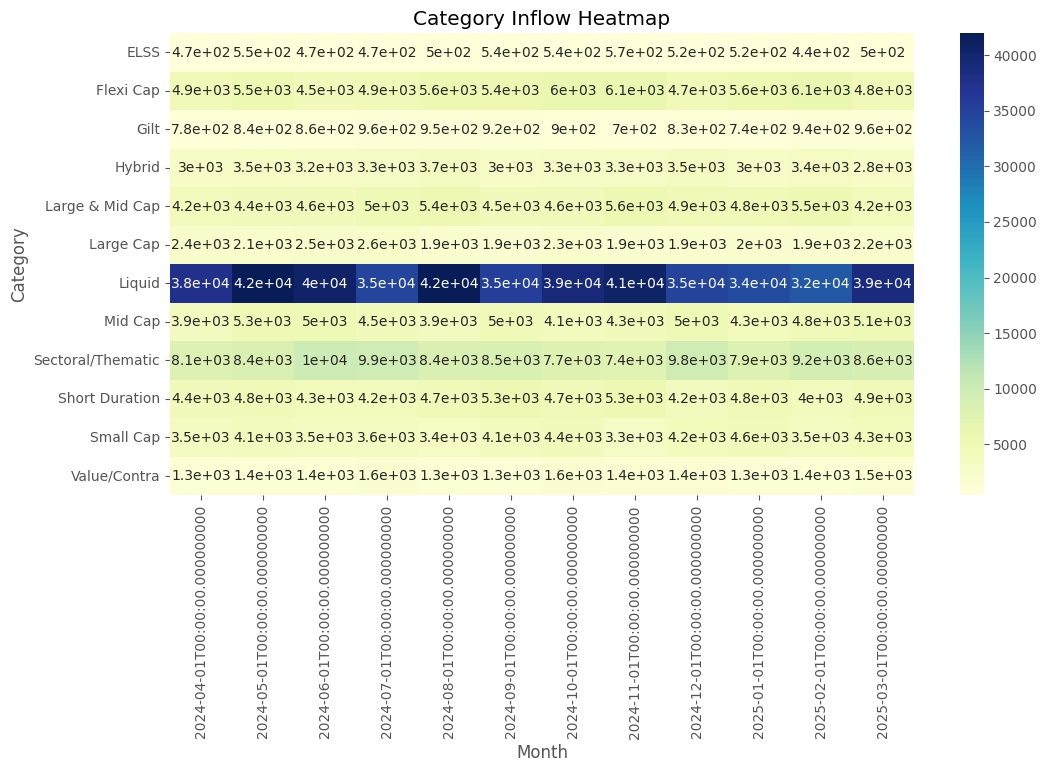

In [24]:
category['month'] = pd.to_datetime(category['month'])

heatmap_data = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.savefig("Category_Inflow_Heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
folio = pd.read_csv("06_industry_folio_count.csv")
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


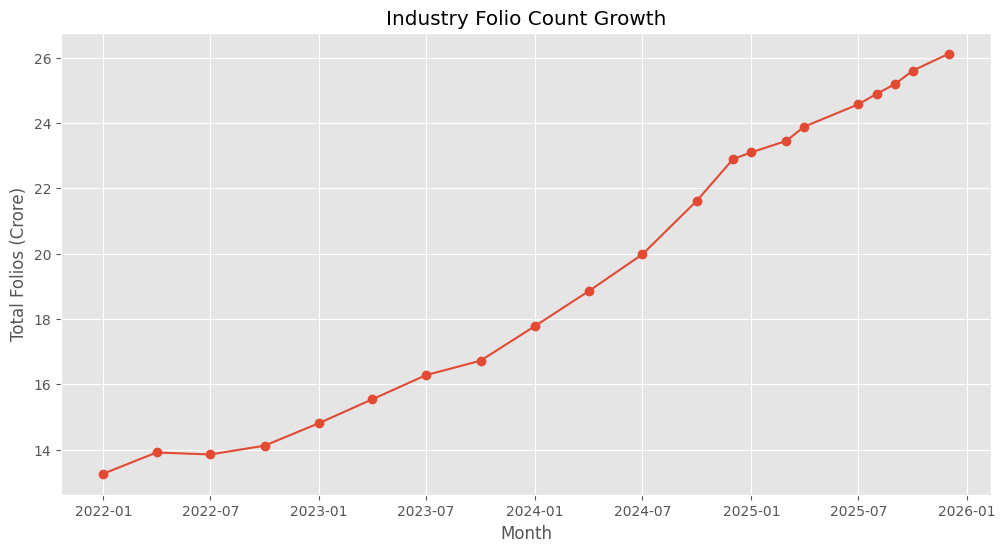

In [26]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))
plt.plot(folio['month'], folio['total_folios_crore'], marker='o')

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.savefig("Industry_Folio_Count_Growth.png", dpi=300, bbox_inches="tight")

plt.show()

In [27]:
performance = pd.read_csv("07_scheme_performance.csv")
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


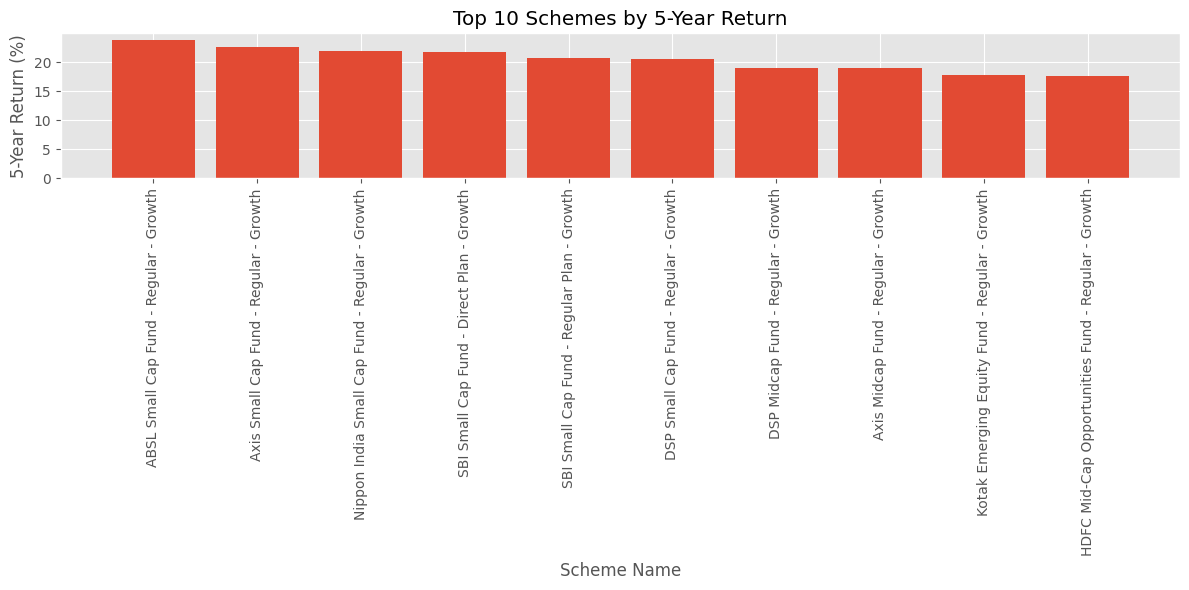

In [28]:
top10 = performance.sort_values(by='return_5yr_pct', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10['scheme_name'], top10['return_5yr_pct'])
plt.xticks(rotation=90)
plt.title("Top 10 Schemes by 5-Year Return")
plt.xlabel("Scheme Name")
plt.ylabel("5-Year Return (%)")
plt.tight_layout()

plt.savefig("Top10_5Year_Return.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
transactions = pd.read_csv("08_investor_transactions.csv")
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


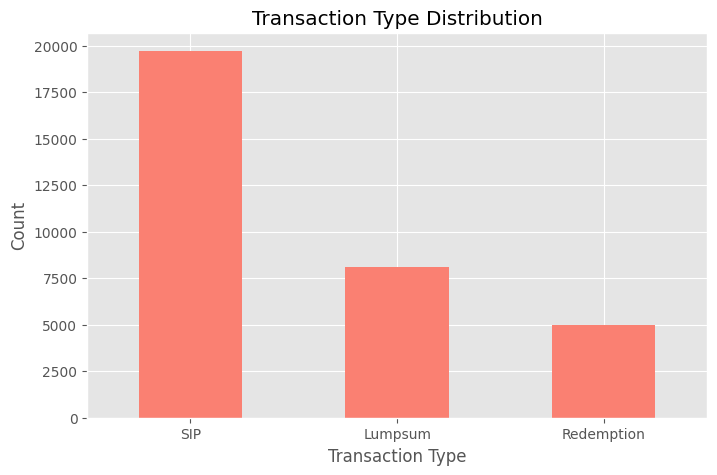

In [31]:
import matplotlib.pyplot as plt

transaction_counts = transactions['transaction_type'].value_counts()

plt.figure(figsize=(8,5))
transaction_counts.plot(kind='bar', color='salmon')

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.savefig("Transaction_Type_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
portfolio = pd.read_csv("09_portfolio_holdings.csv")
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


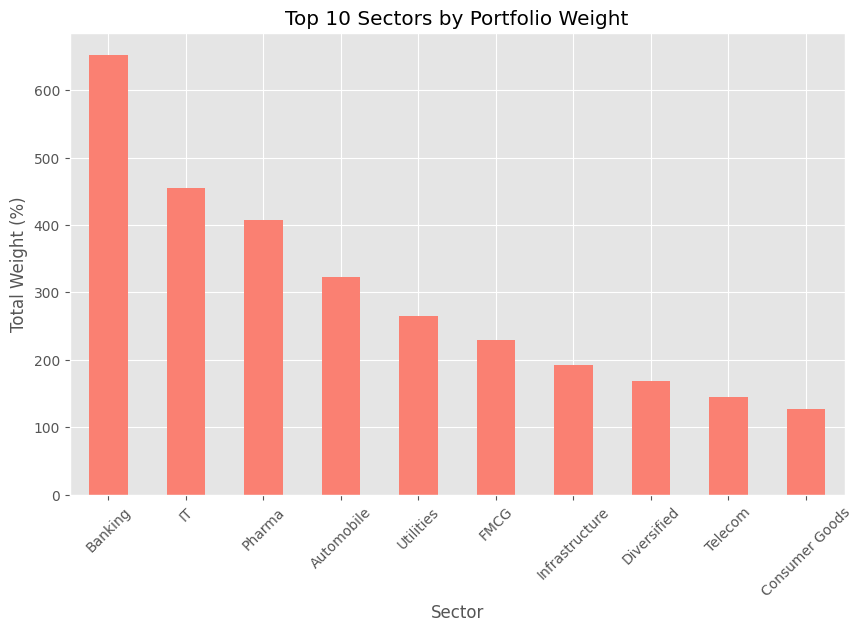

In [33]:
import matplotlib.pyplot as plt

top_sector = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_sector.plot(kind='bar', color='salmon')

plt.title("Top 10 Sectors by Portfolio Weight")
plt.xlabel("Sector")
plt.ylabel("Total Weight (%)")
plt.xticks(rotation=45)

plt.savefig("Top10_Sectors_Portfolio.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
fund = pd.read_csv("01_fund_master.csv")
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


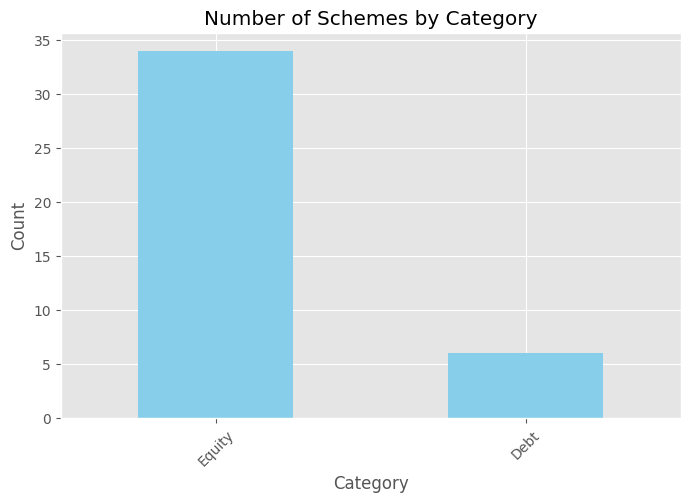

In [35]:


category_counts = fund["category"].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind="bar", color="skyblue")

plt.title("Number of Schemes by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.savefig("Fund_Category_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
benchmark = pd.read_csv("10_benchmark_indices.csv")
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


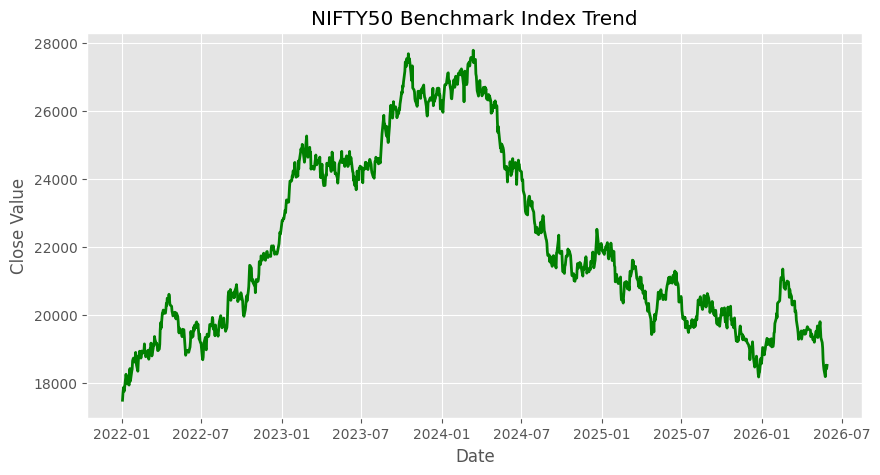

In [37]:

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty = benchmark[benchmark["index_name"] == "NIFTY50"]

plt.figure(figsize=(10,5))
plt.plot(nifty["date"], nifty["close_value"], color="green", linewidth=2)

plt.title("NIFTY50 Benchmark Index Trend")
plt.xlabel("Date")
plt.ylabel("Close Value")
plt.grid(True)

plt.savefig("Benchmark_Index_Trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')